# Figure 6 | Joint scRNA-seq + scATAC-seq Integration with FactorAnalysis

Joint multi-omic integration of 10x Multiome data (E18 mouse brain, 4,878 cells) on a single shared latent space using **`sklearn.decomposition.FactorAnalysis`** — the same dimensionality-reduction backbone scJDO uses for the RNA-only pipeline.

**Why FactorAnalysis works for joint multi-omic integration.** The FA generative model
$$\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\varepsilon},\quad \mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}),\quad \boldsymbol{\varepsilon}\sim\mathcal{N}(\mathbf{0},\boldsymbol{\Psi})$$
extends trivially to two modalities by stacking features: $\mathbf{x}=[\mathbf{x}_{\text{RNA}};\mathbf{x}_{\text{ATAC}}]$ and $\mathbf{W}=[\mathbf{W}_{\text{RNA}};\mathbf{W}_{\text{ATAC}}]$. The shared latent $\mathbf{z}$ explains co-variation across both modalities, while the **diagonal feature-specific noise $\boldsymbol{\Psi}$** absorbs modality-specific technical noise — this is precisely the structure that makes FA the natural multi-omic factorization (and what MOFA generalizes with Bayesian sparsity priors).

| Step | Operation | Detail |
|---|---|---|
| 1 | Load 10x Multiome | `cellranger-arc-2.0.0` filtered matrix (RNA + Peaks) |
| 2 | RNA preprocessing | normalize + log1p + top HVGs |
| 3 | ATAC preprocessing | TF-IDF + top variable peaks |
| 4 | Modality balancing | per-feature standardization + per-block √(1/d) weighting |
| 5 | Joint FA | `FactorAnalysis(n_components=30)` on $[\mathbf{X}_{\text{RNA}}\,|\,\mathbf{X}_{\text{ATAC}}]$ |
| 6 | Downstream | UMAP + Leiden on joint latent |
| 7 | Interpretation | Per-factor modality contribution + top genes/peaks |
| 8 | Controls | RNA-only FA and ATAC-only FA on same data |

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import scjdo as sjd
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.family':  'DejaVu Sans',
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

# ── Dataset ─────────────────────────────────────────────────────────────
DATA_DIR = '/Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/multiomic/filtered_feature_bc_matrix'

# ── Pipeline config ─────────────────────────────────────────────────────────
N_HVG          = 2000     # top variable genes
N_VAR_PEAKS    = 10000    # top variable ATAC peaks (post-TF-IDF)
N_LATENT       = 30       # shared FA factors
FA_MAX_ITER    = 1000     # FactorAnalysis EM max iterations
TFIDF_SCALE    = 1e4      # Signac-style scaling inside log1p
MIN_CELLS_PEAK = 25       # drop ultra-rare peaks (open in <25 cells)
MIN_CELLS_GENE = 10
SEED           = 42

# ── Output ───────────────────────────────────────────────────────────────────
OUTDIR = 'results/figure6_multiome_fa/'
os.makedirs(OUTDIR, exist_ok=True)

MODALITY_COLORS = {'RNA': '#E63946', 'ATAC': '#457B9D', 'Joint': '#2A9D8F'}

print(f'scjdo v{sjd.__version__}  |  scanpy v{sc.__version__}')
print(f'Joint latent: FactorAnalysis ({N_LATENT}-D)  |  RNA HVG={N_HVG}  ATAC peaks={N_VAR_PEAKS}')

scjdo v0.3.0  |  scanpy v1.11.5
Joint latent: FactorAnalysis (30-D)  |  RNA HVG=2000  ATAC peaks=10000


## Step 1 — Load 10x Multiome (RNA + ATAC in one matrix)

`cellranger-arc` writes both modalities into a single filtered matrix. The `feature_types` column in `features.tsv.gz` separates them (`Gene Expression` vs `Peaks`).

In [2]:
# ── Step 1: Load joint 10x Multiome matrix ───────────────────────────────────────────
ad_full = sc.read_10x_mtx(DATA_DIR, gex_only=False, cache=False)
ad_full.var_names_make_unique()
print(f'Joint matrix: {ad_full.n_obs} cells × {ad_full.n_vars} features')
print(f'Feature types:\n{ad_full.var["feature_types"].value_counts().to_string()}')

# Split into modality-specific views (no copy yet)
is_rna  = (ad_full.var['feature_types'] == 'Gene Expression').values
is_atac = (ad_full.var['feature_types'] == 'Peaks').values

ad_rna  = ad_full[:, is_rna].copy()
ad_atac = ad_full[:, is_atac].copy()
del ad_full

print(f'\nRNA  : {ad_rna.n_obs} cells × {ad_rna.n_vars} genes')
print(f'ATAC : {ad_atac.n_obs} cells × {ad_atac.n_vars} peaks')

Joint matrix: 4878 cells × 204478 features
Feature types:
feature_types
Peaks              172193
Gene Expression     32285

RNA  : 4878 cells × 32285 genes
ATAC : 4878 cells × 172193 peaks


## Step 2 — RNA preprocessing (normalize + log + HVG)
Standard scRNA-seq normalization. HVG selection picks the genes that actually carry shared biological signal — essential for FA, which would otherwise spend variance on ribosomal/mitochondrial bulk.

In [3]:
# ── Step 2: RNA preprocessing ────────────────────────────────────────────────────────────
sc.pp.filter_genes(ad_rna, min_cells=MIN_CELLS_GENE)
ad_rna.layers['raw_counts'] = ad_rna.X.copy()

sc.pp.normalize_total(ad_rna, target_sum=1e4)
sc.pp.log1p(ad_rna)
sc.pp.highly_variable_genes(ad_rna, n_top_genes=N_HVG, flavor='seurat')

rna_hvg_mask = ad_rna.var['highly_variable'].values
X_rna = ad_rna[:, rna_hvg_mask].X
X_rna = X_rna.toarray() if sp.issparse(X_rna) else np.asarray(X_rna)
X_rna = X_rna.astype(np.float32)
print(f'RNA HVG matrix: {X_rna.shape} (dense, float32)  |  {X_rna.nbytes/1e6:.1f} MB')

RNA HVG matrix: (4878, 2000) (dense, float32)  |  39.0 MB


## Step 3 — ATAC preprocessing (TF-IDF + variable peaks)

ATAC counts are binarized in expectation (a peak is either open or not) and dominated by extreme sparsity. The standard transform is **TF-IDF**: down-weight peaks open in nearly every cell (uninformative) and up-weight rare-but-cell-discriminating peaks.

$$\text{TF-IDF}_{ij} = \frac{x_{ij}}{\sum_k x_{ik}}\cdot \log\!\left(1 + \frac{n_{\text{cells}}}{1 + \mathrm{df}_j}\right)$$

Followed by `log1p(TF-IDF × 10^4)` (Signac convention) so the result behaves like log-normalized expression.

In [4]:
# ── Step 3: ATAC TF-IDF + variable peak selection ────────────────────────────────────────
sc.pp.filter_genes(ad_atac, min_cells=MIN_CELLS_PEAK)
ad_atac.layers['raw_counts'] = ad_atac.X.copy()

def tfidf_transform(X, scale=1e4):
    """Signac-style TF-IDF → log1p, returns sparse log-TF-IDF and the IDF vector."""
    X = X.tocsr().astype(np.float32)
    n_cells = X.shape[0]
    cell_totals = np.asarray(X.sum(axis=1)).ravel()
    cell_totals[cell_totals == 0] = 1.0
    peak_df = np.asarray((X > 0).sum(axis=0)).ravel()
    idf = np.log(1.0 + n_cells / (1.0 + peak_df)).astype(np.float32)
    # TF (row-normalize), then multiply by IDF column-wise
    inv_totals = sp.diags(1.0 / cell_totals)
    tf = inv_totals @ X
    tfidf = tf.multiply(idf[None, :])
    # Signac: log1p(tfidf * 10^4)
    tfidf.data = np.log1p(tfidf.data * scale)
    return tfidf.tocsr(), idf

X_atac_full, idf = tfidf_transform(ad_atac.X, scale=TFIDF_SCALE)
ad_atac.layers['log_tfidf'] = X_atac_full

# Variable peak selection — per-peak variance of the log-TF-IDF
mean_sq = np.asarray(X_atac_full.multiply(X_atac_full).mean(axis=0)).ravel()
mean    = np.asarray(X_atac_full.mean(axis=0)).ravel()
peak_var = mean_sq - mean**2
ad_atac.var['variance_tfidf'] = peak_var

top_idx = np.argsort(peak_var)[::-1][:N_VAR_PEAKS]
atac_var_mask = np.zeros(ad_atac.n_vars, dtype=bool)
atac_var_mask[top_idx] = True
ad_atac.var['variable'] = atac_var_mask

X_atac = X_atac_full[:, atac_var_mask].toarray().astype(np.float32)
print(f'ATAC variable-peak matrix: {X_atac.shape} (dense, float32)  |  {X_atac.nbytes/1e6:.1f} MB')
del X_atac_full

ATAC variable-peak matrix: (4878, 10000) (dense, float32)  |  195.1 MB


## Step 3b — Cell-cycle regression (RNA + ATAC, before integration)

Per-feature linear residualisation of **both** modalities against S- and
G2M-phase scores computed on RNA. The standard mouse Tirosh marker set is
used. Both modality matrices are residualised before standardisation,
balancing, and joint FactorAnalysis — so cell-cycle variance is removed
**before** any cross-modal coupling is learned.

If you ever need to disable this step (e.g. to compare against the
uncorrected pipeline), set `DO_CC_REGRESSION = False` in the cell below.


In [5]:
# ── Step 3b: Score S/G2M on RNA, regress out from both modality matrices ─────
DO_CC_REGRESSION = True

# Tirosh et al. 2016 cell-cycle markers, mouse symbols.
S_GENES = [
    'Mcm5','Pcna','Tyms','Fen1','Mcm2','Mcm4','Rrm1','Ung','Gins2','Mcm6',
    'Cdca7','Dtl','Prim1','Uhrf1','Mlf1ip','Hells','Rfc2','Rpa2','Nasp',
    'Rad51ap1','Gmnn','Wdr76','Slbp','Ccne2','Ubr7','Pold3','Msh2','Atad2',
    'Rad51','Rrm2','Cdc45','Cdc6','Exo1','Tipin','Dscc1','Blm','Casp8ap2',
    'Usp1','Clspn','Pola1','Chaf1b','Brip1','E2f8',
]
G2M_GENES = [
    'Hmgb2','Cdk1','Nusap1','Ube2c','Birc5','Tpx2','Top2a','Ndc80','Cks2',
    'Nuf2','Cks1b','Mki67','Tmpo','Cenpf','Tacc3','Fam64a','Smc4','Ccnb2',
    'Ckap2l','Ckap2','Aurkb','Bub1','Kif11','Anp32e','Tubb4b','Gtse1',
    'Kif20b','Hjurp','Cdca3','Hn1','Cdc20','Ttk','Cdc25c','Kif2c','Rangap1',
    'Ncapd2','Dlgap5','Cdca2','Cdca8','Ect2','Kif23','Hmmr','Aurka','Psrc1',
    'Anln','Lbr','Ckap5','Cenpe','Ctcf','Nek2','G2e3','Gas2l3','Cbx5','Cenpa',
]
S_GENES   = [g for g in S_GENES   if g in ad_rna.var_names]
G2M_GENES = [g for g in G2M_GENES if g in ad_rna.var_names]
print(f'S markers present  : {len(S_GENES)}')
print(f'G2M markers present: {len(G2M_GENES)}')

if not DO_CC_REGRESSION:
    print('[skip] DO_CC_REGRESSION = False — leaving RNA/ATAC matrices unchanged')
else:
    # Score on the full log-normalised RNA (ad_rna.X has log1p(normalized))
    sc.tl.score_genes_cell_cycle(ad_rna, s_genes=S_GENES, g2m_genes=G2M_GENES)
    print('\nPhase composition (RNA):')
    print(ad_rna.obs['phase'].value_counts().to_string())

    S   = ad_rna.obs['S_score'  ].values.astype(np.float32)
    G2M = ad_rna.obs['G2M_score'].values.astype(np.float32)
    Z   = np.column_stack([np.ones(len(S), dtype=np.float32), S, G2M]).astype(np.float32)

    def residualise(X, Z):
        # Per-column OLS; returns residuals X - Z @ (Z^T Z)^{-1} Z^T X.
        beta = np.linalg.lstsq(Z, X, rcond=None)[0]
        return (X - Z @ beta).astype(np.float32)

    # Variance accounting BEFORE
    var_rna_before  = float((X_rna  ** 2).sum() / X_rna.shape[0])
    var_atac_before = float((X_atac ** 2).sum() / X_atac.shape[0])

    X_rna  = residualise(X_rna,  Z)
    X_atac = residualise(X_atac, Z)

    var_rna_after  = float((X_rna  ** 2).sum() / X_rna.shape[0])
    var_atac_after = float((X_atac ** 2).sum() / X_atac.shape[0])

    print(f'\nRNA  matrix variance:  before = {var_rna_before:.4f}   '
          f'after = {var_rna_after:.4f}   removed = {(1-var_rna_after/var_rna_before)*100:.1f}%')
    print(f'ATAC matrix variance:  before = {var_atac_before:.4f}   '
          f'after = {var_atac_after:.4f}   removed = {(1-var_atac_after/var_atac_before)*100:.1f}%')

    # Persist scores for downstream notebooks (the drift notebook reads ad.obs)
    ad_rna.obs['S_score_pre_integration']   = ad_rna.obs['S_score']
    ad_rna.obs['G2M_score_pre_integration'] = ad_rna.obs['G2M_score']


S markers present  : 42
G2M markers present: 52

Phase composition (RNA):
phase
G1     3691
S       623
G2M     564

RNA  matrix variance:  before = 515.4626   after = 340.7231   removed = 33.9%
ATAC matrix variance:  before = 3558.6887   after = 2506.3516   removed = 29.6%


## Step 4 — Balance modalities and concatenate

Without balancing, the modality with more features and larger raw variance dominates the shared latent space. We:
1. **Standardize each feature to zero mean / unit variance** (per modality).
2. **Scale each block by $1/\sqrt{d_m}$** where $d_m$ is the number of features in modality $m$ — this makes each modality contribute equal total Frobenius variance to the concatenated matrix.

After balancing, $\|\mathbf{X}_{\text{RNA}}\|_F^2 = \|\mathbf{X}_{\text{ATAC}}\|_F^2$ regardless of feature count.

In [6]:
# ── Step 4: Per-feature standardization + per-modality variance balancing ────────────────────
scaler_rna  = StandardScaler(with_mean=True, with_std=True).fit(X_rna)
scaler_atac = StandardScaler(with_mean=True, with_std=True).fit(X_atac)
X_rna_s  = scaler_rna.transform(X_rna).astype(np.float32)
X_atac_s = scaler_atac.transform(X_atac).astype(np.float32)

# Equal Frobenius variance per modality
w_rna  = 1.0 / np.sqrt(X_rna_s.shape[1])
w_atac = 1.0 / np.sqrt(X_atac_s.shape[1])
X_rna_w  = X_rna_s  * w_rna
X_atac_w = X_atac_s * w_atac

X_joint = np.concatenate([X_rna_w, X_atac_w], axis=1)
n_rna_feats  = X_rna_w.shape[1]
n_atac_feats = X_atac_w.shape[1]
feat_modality = np.array(['RNA']*n_rna_feats + ['ATAC']*n_atac_feats)
feat_names    = np.concatenate([
    ad_rna.var_names[rna_hvg_mask].values,
    ad_atac.var_names[atac_var_mask].values,
])

var_rna  = float((X_rna_w**2).sum() / X_rna_w.shape[0])
var_atac = float((X_atac_w**2).sum() / X_atac_w.shape[0])
print(f'Joint matrix: {X_joint.shape}  ({X_joint.nbytes/1e6:.1f} MB)')
print(f'RNA  block total variance:  {var_rna:.4f}')
print(f'ATAC block total variance:  {var_atac:.4f}   (should match RNA after balancing)')
del X_rna_s, X_atac_s

Joint matrix: (4878, 12000)  (468.3 MB)
RNA  block total variance:  1.0000
ATAC block total variance:  1.0000   (should match RNA after balancing)


## Step 5 — Fit joint FactorAnalysis on $[\mathbf{X}_{\text{RNA}}\,|\,\mathbf{X}_{\text{ATAC}}]$
Same parameters as scJDO's RNA-only pipeline (30 components), but now the loadings $\mathbf{W}$ span both modalities.

In [7]:
# ── Step 5: Joint FactorAnalysis ───────────────────────────────────────────────────────────
import time
t0 = time.time()
fa_joint = FactorAnalysis(n_components=N_LATENT, random_state=SEED, max_iter=FA_MAX_ITER)
Z_joint  = fa_joint.fit_transform(X_joint).astype(np.float32)
print(f'Joint FA fit in {time.time()-t0:.1f}s  |  log-likelihood (final) = {fa_joint.loglike_[-1]:.2f}')
print(f'Z_joint shape: {Z_joint.shape}  (cells × factors)')

# Build joint AnnData carrying both modalities + shared latent
ad_joint = ad_rna.copy()
ad_joint.obsm['X_fa_joint'] = Z_joint
# Loadings (features × factors), zero-padded to full RNA gene space + appended ATAC peaks block
rna_loadings  = fa_joint.components_[:, :n_rna_feats].T.astype(np.float32)     # (n_rna_feats, K)
atac_loadings = fa_joint.components_[:,  n_rna_feats:].T.astype(np.float32)    # (n_atac_feats, K)

# Pad RNA loadings back to full gene set for scjdo compatibility
_rna_full_loadings = np.zeros((ad_rna.n_vars, N_LATENT), dtype=np.float32)
_rna_full_loadings[rna_hvg_mask] = rna_loadings
ad_joint.varm['PCs'] = _rna_full_loadings   # scjdo convention: gene×factor loadings

# Also store ATAC loadings on the ATAC AnnData for interpretation
_atac_full_loadings = np.zeros((ad_atac.n_vars, N_LATENT), dtype=np.float32)
_atac_full_loadings[atac_var_mask] = atac_loadings
ad_atac.varm['FA_loadings'] = _atac_full_loadings
ad_atac.obsm['X_fa_joint']  = Z_joint

Joint FA fit in 1.5s  |  log-likelihood (final) = 181248713.82
Z_joint shape: (4878, 30)  (cells × factors)


## Step 6 — UMAP + Leiden clustering on the joint latent

In [8]:
# ── Step 6: UMAP + Leiden on joint latent ─────────────────────────────────────────────────
sc.pp.neighbors(ad_joint, use_rep='X_fa_joint', n_neighbors=15)
sc.tl.umap(ad_joint, random_state=SEED)

# Robust clustering — try leiden (preferred, modern flavors first), fall back to KMeans
def _cluster_joint(ad, key='leiden_joint', resolution=0.6, seed=SEED):
    # Try modern leiden (scanpy >= 1.10, flavor='igraph')
    try:
        sc.tl.leiden(ad, resolution=resolution, random_state=seed, key_added=key,
                     flavor='igraph', n_iterations=2, directed=False)
        return 'leiden(igraph)'
    except Exception:
        pass
    # Try classic leiden (needs leidenalg)
    try:
        sc.tl.leiden(ad, resolution=resolution, random_state=seed, key_added=key)
        return 'leiden(leidenalg)'
    except Exception:
        pass
    # Fall back to KMeans on the joint latent
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=12, random_state=seed, n_init=10).fit(ad.obsm['X_fa_joint'])
    ad.obs[key] = pd.Categorical(km.labels_.astype(str))
    return 'kmeans(k=12)'

_method = _cluster_joint(ad_joint, key='leiden_joint', resolution=0.6)
ad_atac.obsm['X_umap_joint'] = ad_joint.obsm['X_umap']
ad_atac.obs['leiden_joint']  = ad_joint.obs['leiden_joint'].values
print(f'Clustering method used: {_method}')
print(f'Clusters on joint latent: {ad_joint.obs["leiden_joint"].nunique()}')
print(ad_joint.obs['leiden_joint'].value_counts().sort_index().to_string())


Clustering method used: leiden(igraph)
Clusters on joint latent: 18
leiden_joint
0     617
1     491
2      13
3     147
4     812
5     377
6      23
7     233
8      45
9     262
10    244
11    311
12    433
13    273
14    248
15    204
16    119
17     26


## Step 7 — Per-factor modality contribution

For each joint factor $k$, decompose its total squared loading into RNA vs ATAC blocks:
$$\mathrm{contrib}_{m,k} = \sum_{j\in m} W_{jk}^2 \;\Big/\; \sum_j W_{jk}^2$$
A factor close to 50/50 captures truly shared structure; one heavily skewed is modality-specific.

In [9]:
# ── Step 7: per-factor modality contribution ────────────────────────────────────────────────
W = fa_joint.components_.T  # (n_features, K)
W_sq = W ** 2
rna_mask_W  = (feat_modality == 'RNA')
atac_mask_W = (feat_modality == 'ATAC')

contrib_rna  = W_sq[rna_mask_W ].sum(axis=0)
contrib_atac = W_sq[atac_mask_W].sum(axis=0)
total        = contrib_rna + contrib_atac
frac_rna  = contrib_rna  / np.maximum(total, 1e-12)
frac_atac = contrib_atac / np.maximum(total, 1e-12)

contrib_df = pd.DataFrame({
    'factor':     np.arange(1, N_LATENT+1),
    'rna_frac':   frac_rna,
    'atac_frac':  frac_atac,
    'total_w2':   total,
}).sort_values('total_w2', ascending=False).reset_index(drop=True)
contrib_df.to_csv(OUTDIR + 'factor_modality_contribution.csv', index=False)
print('Top 10 factors by total loading magnitude:')
print(contrib_df.head(10).to_string(index=False))

Top 10 factors by total loading magnitude:
 factor  rna_frac  atac_frac  total_w2
      1  0.074195   0.925805  0.035218
      2  0.957896   0.042104  0.034255
      4  0.889015   0.110985  0.025299
      3  0.943800   0.056200  0.024082
      5  0.895247   0.104753  0.022191
      6  0.879603   0.120397  0.017026
      7  0.980418   0.019582  0.011612
      8  0.865191   0.134809  0.008594
     10  0.909056   0.090944  0.008571
      9  0.961127   0.038873  0.007989


## Step 8 — Top genes and peaks per joint factor
Pull the highest-loading features for each of the top factors — these are the genes and chromatin regions that the shared latent is using.

In [10]:
# ── Step 8: top genes / peaks per factor ─────────────────────────────────────────────────────────
N_TOP = 10
rna_feats_in_joint  = ad_rna.var_names[rna_hvg_mask].values
atac_feats_in_joint = ad_atac.var_names[atac_var_mask].values

factor_top = {}
for k in range(N_LATENT):
    w_rna_k  = rna_loadings[:, k]
    w_atac_k = atac_loadings[:, k]
    top_rna_idx  = np.argsort(np.abs(w_rna_k))[::-1][:N_TOP]
    top_atac_idx = np.argsort(np.abs(w_atac_k))[::-1][:N_TOP]
    factor_top[k+1] = {
        'top_genes': list(zip(rna_feats_in_joint[top_rna_idx], w_rna_k[top_rna_idx].astype(float))),
        'top_peaks': list(zip(atac_feats_in_joint[top_atac_idx], w_atac_k[top_atac_idx].astype(float))),
    }

# Save the top-5 in a tidy table
rows = []
for k, d in factor_top.items():
    rows.append({
        'factor': k,
        'rna_frac':  float(frac_rna[k-1]),
        'atac_frac': float(frac_atac[k-1]),
        'top_genes': ', '.join([g for g,_ in d['top_genes'][:5]]),
        'top_peaks': ', '.join([p for p,_ in d['top_peaks'][:5]]),
    })
top_df = pd.DataFrame(rows)
top_df.to_csv(OUTDIR + 'factor_top_features.csv', index=False)
print(top_df.head(15).to_string(index=False))

 factor  rna_frac  atac_frac                               top_genes                                                                                                                    top_peaks
      1  0.074195   0.925805           Lrfn5, Mdga2, Sybu, Grm5, Nin chr2:98666601-98667378, chr1:88277159-88278024, chr11:120572663-120573596, chr2:164879230-164880164, chr11:77982186-77982912
      2  0.957896   0.042104 Fli1, Rasgrp3, Selenop, Slco2b1, Inpp5d   chr19:61266349-61267212, chr10:58322916-58323822, chr15:58076059-58076971, chr13:60177125-60178027, chr8:84712123-84713042
      3  0.943800   0.056200       Fcrls, Trem2, Adgre1, C1qb, Csf1r chr8:84712123-84713042, chr1:134063014-134063755, chr14:25317694-25318608, chr11:77893782-77894581, chr4:120188430-120189330
      4  0.889015   0.110985       Gli3, Creb5, Tnc, Gm29260, Prdm16  chr8:84712123-84713042, chr18:45896453-45897381, chr15:85993827-85994712, chr4:120188430-120189330, chr11:77893782-77894581
      5  0.895247   0.104753  

## Step 9 — Single-modality FA controls

Fit FA on each modality alone and compare — this shows what structure is recoverable from RNA-only or ATAC-only, and how much is gained by sharing the latent across both.

In [11]:
# ── Step 9: RNA-only and ATAC-only FA ──────────────────────────────────────────────────────
t0 = time.time()
fa_rna  = FactorAnalysis(n_components=N_LATENT, random_state=SEED, max_iter=FA_MAX_ITER)
Z_rna   = fa_rna.fit_transform(X_rna).astype(np.float32)
print(f'RNA-only FA  fit in {time.time()-t0:.1f}s')

t0 = time.time()
fa_atac = FactorAnalysis(n_components=N_LATENT, random_state=SEED, max_iter=FA_MAX_ITER)
Z_atac  = fa_atac.fit_transform(X_atac).astype(np.float32)
print(f'ATAC-only FA fit in {time.time()-t0:.1f}s')

# Per-modality UMAPs
ad_joint.obsm['X_fa_rna']  = Z_rna
ad_joint.obsm['X_fa_atac'] = Z_atac
for rep, ukey in [('X_fa_rna', 'X_umap_rna'), ('X_fa_atac', 'X_umap_atac')]:
    sc.pp.neighbors(ad_joint, use_rep=rep, n_neighbors=15, key_added=rep+'_nbr')
    sc.tl.umap(ad_joint, neighbors_key=rep+'_nbr', random_state=SEED)
    ad_joint.obsm[ukey] = ad_joint.obsm['X_umap'].copy()

# Restore the joint UMAP as the default 'X_umap'
sc.pp.neighbors(ad_joint, use_rep='X_fa_joint', n_neighbors=15)
sc.tl.umap(ad_joint, random_state=SEED)

RNA-only FA  fit in 0.3s
ATAC-only FA fit in 1.1s


## Step 9b — Integration QC: did joint FA actually integrate RNA + ATAC?

Four quantitative checks of the joint latent against the single-modality baselines:

1. **Modality-depth mixing** — joint UMAP colored by total RNA UMIs and ATAC fragments. Smooth spatial distribution means the joint latent isn't dominated by per-cell library size.
2. **Cluster preservation** — Leiden on `X_fa_rna` and `X_fa_atac`; ARI/NMI against `leiden_joint`. High agreement = joint structure consistent with each modality.
3. **kNN overlap (joint vs single-modality)** — per cell, fraction of joint-space k-nearest-neighbors that are also kNN in the RNA-only or ATAC-only embedding. Tells you whether neighborhoods are dominated by one modality.
4. **Marker × promoter peak colocalization** — for canonical E18 brain markers, does the RNA expression and the promoter peak accessibility light up the same region of the joint UMAP?


In [12]:
# ── Step 9b: Integration QC — compute all four metrics ─────────────────────────
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import bisect

# 1. Per-cell modality depth (from raw counts kept in layers)
rna_umi  = np.asarray(ad_joint.layers['raw_counts'].sum(axis=1)).ravel().astype(np.float32)
atac_frg = np.asarray(ad_atac.layers['raw_counts'].sum(axis=1)).ravel().astype(np.float32)
ad_joint.obs['rna_umi']  = rna_umi
ad_joint.obs['atac_frag'] = atac_frg
print(f'RNA UMI per cell:     median={np.median(rna_umi):.0f}   IQR=[{np.percentile(rna_umi,25):.0f}, {np.percentile(rna_umi,75):.0f}]')
print(f'ATAC frag per cell:   median={np.median(atac_frg):.0f}   IQR=[{np.percentile(atac_frg,25):.0f}, {np.percentile(atac_frg,75):.0f}]')

# 2. Cluster single-modality embeddings — robust fallback like Step 6
def _cluster_rep(ad, use_rep, key_added, neighbors_key, resolution=0.6, seed=SEED):
    if neighbors_key not in ad.uns:
        sc.pp.neighbors(ad, use_rep=use_rep, n_neighbors=15, key_added=neighbors_key)
    for kwargs in [dict(flavor='igraph', n_iterations=2, directed=False), dict()]:
        try:
            sc.tl.leiden(ad, resolution=resolution, random_state=seed,
                         key_added=key_added, neighbors_key=neighbors_key, **kwargs)
            return f'leiden({"igraph" if "flavor" in kwargs else "leidenalg"})'
        except Exception:
            continue
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=12, random_state=seed, n_init=10).fit(ad.obsm[use_rep])
    ad.obs[key_added] = pd.Categorical(km.labels_.astype(str))
    return 'kmeans(k=12)'

m_rna  = _cluster_rep(ad_joint, 'X_fa_rna',  'leiden_rna',  'X_fa_rna_nbr')
m_atac = _cluster_rep(ad_joint, 'X_fa_atac', 'leiden_atac', 'X_fa_atac_nbr')
print(f'\nClustering:')
print(f'  joint  : {ad_joint.obs["leiden_joint"].nunique():2d} clusters')
print(f'  RNA    : {ad_joint.obs["leiden_rna"].nunique():2d} clusters  ({m_rna})')
print(f'  ATAC   : {ad_joint.obs["leiden_atac"].nunique():2d} clusters  ({m_atac})')

# ARI / NMI between the three label sets
joint_lbl = ad_joint.obs['leiden_joint'].astype(str).values
rna_lbl   = ad_joint.obs['leiden_rna'  ].astype(str).values
atac_lbl  = ad_joint.obs['leiden_atac' ].astype(str).values
similarity_df = pd.DataFrame({
    'pair':  ['joint vs RNA-only', 'joint vs ATAC-only', 'RNA-only vs ATAC-only'],
    'ARI':   [adjusted_rand_score(joint_lbl, rna_lbl),
              adjusted_rand_score(joint_lbl, atac_lbl),
              adjusted_rand_score(rna_lbl, atac_lbl)],
    'NMI':   [normalized_mutual_info_score(joint_lbl, rna_lbl),
              normalized_mutual_info_score(joint_lbl, atac_lbl),
              normalized_mutual_info_score(rna_lbl, atac_lbl)],
})
similarity_df.round(3).to_csv(OUTDIR + 'integration_qc_clustering_similarity.csv', index=False)
print('\nClustering similarity:')
print(similarity_df.round(3).to_string(index=False))

# 3. kNN overlap (joint vs single-modality)
K_NN = 30
def _knn_idx(X, k=K_NN):
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)
    return nn.kneighbors(X, return_distance=False)[:, 1:]

joint_nn = _knn_idx(ad_joint.obsm['X_fa_joint'])
rna_nn   = _knn_idx(ad_joint.obsm['X_fa_rna'])
atac_nn  = _knn_idx(ad_joint.obsm['X_fa_atac'])

ovl_rna  = np.array([len(set(j) & set(r))/K_NN for j, r in zip(joint_nn, rna_nn )], dtype=np.float32)
ovl_atac = np.array([len(set(j) & set(a))/K_NN for j, a in zip(joint_nn, atac_nn)], dtype=np.float32)
ad_joint.obs['knn_overlap_rna']  = ovl_rna
ad_joint.obs['knn_overlap_atac'] = ovl_atac

# Per joint-cluster aggregate
overlap_by_cluster = pd.DataFrame({
    'cluster':    ad_joint.obs['leiden_joint'].astype(str).values,
    'ovl_rna':    ovl_rna,
    'ovl_atac':   ovl_atac,
}).groupby('cluster').mean().sort_index()
overlap_by_cluster.to_csv(OUTDIR + 'integration_qc_knn_overlap.csv')
print(f'\nPer-cell kNN overlap (k={K_NN}):')
print(f'  joint vs RNA   : median={np.median(ovl_rna):.3f}  mean={ovl_rna.mean():.3f}')
print(f'  joint vs ATAC  : median={np.median(ovl_atac):.3f}  mean={ovl_atac.mean():.3f}')

# 4. Marker gene × promoter peak — load feature coords and build promoter map
DATA_DIR_FEAT = '/Users/terooatt/Documents/Project_scQDiff/02_scQDiff/scIDIFF_anndata/data/multiomic/filtered_feature_bc_matrix'
feat_df = pd.read_csv(DATA_DIR_FEAT + '/features.tsv.gz', sep='\t', header=None,
                      names=['feature_id', 'feature_name', 'feature_type', 'chrom', 'start', 'end'])
gene_coords = feat_df[feat_df.feature_type == 'Gene Expression'].set_index('feature_name')
gene_coords = gene_coords[~gene_coords.index.duplicated(keep='first')]
peak_coords = feat_df[feat_df.feature_type == 'Peaks'].set_index('feature_id')
peak_coords = peak_coords.loc[peak_coords.index.intersection(ad_atac.var_names)]

PROMOTER_KB = 5  # tight window for promoter
peaks_by_chrom = {}
for chrom, sub in peak_coords.groupby('chrom'):
    centers = ((sub['start'].values + sub['end'].values) / 2).astype(np.int64)
    order = np.argsort(centers)
    peaks_by_chrom[chrom] = {'names': sub.index.values[order], 'centers': centers[order]}

def promoter_peaks(gene_name, kb=PROMOTER_KB):
    if gene_name not in gene_coords.index: return []
    row = gene_coords.loc[gene_name]
    d = peaks_by_chrom.get(row['chrom'])
    if d is None: return []
    tss, w = int(row['start']), kb*1000
    lo = bisect.bisect_left(d['centers'], tss - w)
    hi = bisect.bisect_right(d['centers'], tss + w)
    return d['names'][lo:hi].tolist()

MARKERS = ['Sox2', 'Pax6', 'Tbr1', 'Dlx1', 'Pdgfra', 'Reln']
marker_data = {}
for marker in MARKERS:
    if marker not in ad_joint.var_names:
        print(f'  [skip] {marker}: not in RNA var')
        continue
    X = ad_joint[:, marker].X
    rna_expr = X.toarray().ravel() if sp.issparse(X) else np.asarray(X).ravel()
    peaks = promoter_peaks(marker)
    if peaks:
        cols = [ad_atac.var_names.get_loc(p) for p in peaks if p in ad_atac.var_names]
        atac_acc = np.asarray(ad_atac.layers['log_tfidf'][:, cols].mean(axis=1)).ravel()
    else:
        atac_acc = np.zeros(ad_joint.n_obs, dtype=np.float32)
    marker_data[marker] = (rna_expr.astype(np.float32), atac_acc.astype(np.float32), len(peaks))
    print(f'  {marker:8s}: {len(peaks)} promoter peaks (±{PROMOTER_KB} kb of TSS)')

print(f'\nIntegration QC computations complete.')


RNA UMI per cell:     median=7982   IQR=[5379, 11851]
ATAC frag per cell:   median=17550   IQR=[9302, 27517]

Clustering:
  joint  : 18 clusters
  RNA    : 20 clusters  (leiden(igraph))
  ATAC   :  8 clusters  (leiden(igraph))

Clustering similarity:
                 pair   ARI   NMI
    joint vs RNA-only 0.512 0.698
   joint vs ATAC-only 0.310 0.422
RNA-only vs ATAC-only 0.192 0.325

Per-cell kNN overlap (k=30):
  joint vs RNA   : median=0.400  mean=0.399
  joint vs ATAC  : median=0.133  mean=0.151
  Sox2    : 3 promoter peaks (±5 kb of TSS)
  Pax6    : 0 promoter peaks (±5 kb of TSS)
  Tbr1    : 3 promoter peaks (±5 kb of TSS)
  Dlx1    : 2 promoter peaks (±5 kb of TSS)
  Pdgfra  : 4 promoter peaks (±5 kb of TSS)
  Reln    : 1 promoter peaks (±5 kb of TSS)

Integration QC computations complete.


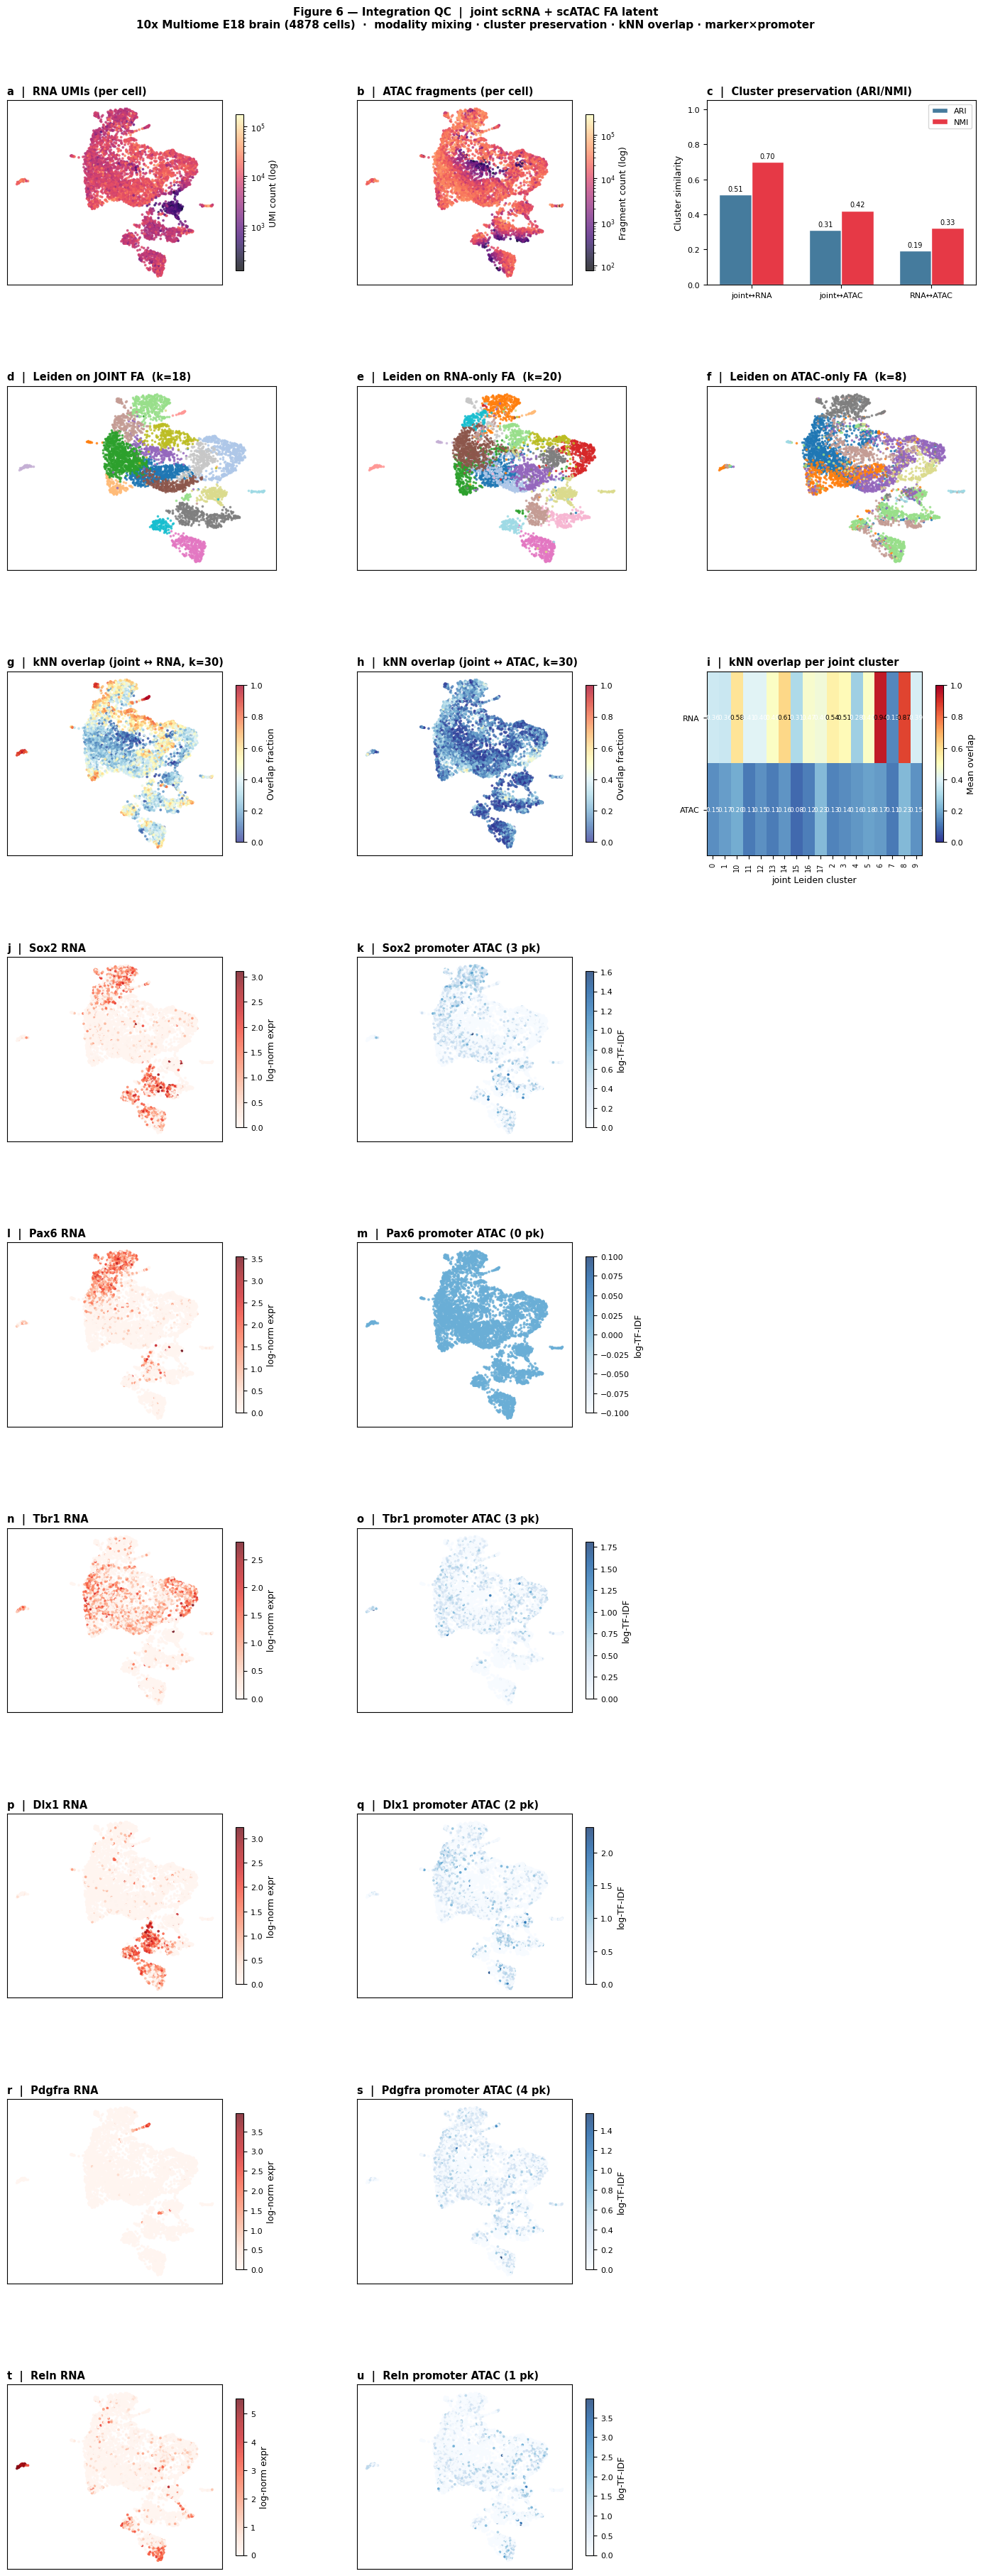

Saved integration QC figure → results/figure6_multiome_fa/Figure6_integration_QC.pdf / .png


In [13]:
# ── Step 9b cont: Integration QC figure (15 panels) ───────────────────────────────
from matplotlib.colors import LogNorm

n_markers = len(marker_data)
n_marker_rows = n_markers              # 1 marker per row (RNA | ATAC | blank)
n_rows = 3 + n_marker_rows
fig = plt.figure(figsize=(15, 4.2 * n_rows))
gs  = gridspec.GridSpec(n_rows, 3, hspace=0.55, wspace=0.30,
                        left=0.06, right=0.97, top=0.96, bottom=0.04)

umap = ad_joint.obsm['X_umap']

def _scatter(ax, c, cmap, title, letter, log=False, vmin=None, vmax=None, cbar_label=None):
    norm = LogNorm(vmin=max(1, np.min(c[c>0])), vmax=np.max(c)) if log else None
    if log:
        im = ax.scatter(umap[:, 0], umap[:, 1], c=c, cmap=cmap, s=3, alpha=0.75,
                        norm=norm, rasterized=True)
    else:
        im = ax.scatter(umap[:, 0], umap[:, 1], c=c, cmap=cmap, s=3, alpha=0.75,
                        vmin=vmin, vmax=vmax, rasterized=True)
    plt.colorbar(im, ax=ax, shrink=0.85, label=cbar_label or '')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{letter}  |  {title}', fontweight='bold', loc='left', fontsize=10.5)

def _scatter_clusters(ax, labels, title, letter):
    unique = sorted(set(labels), key=lambda c: int(c) if str(c).isdigit() else c)
    palette = plt.get_cmap('tab20')(np.linspace(0, 1, max(len(unique), 3)))
    for i, c in enumerate(unique):
        m = np.asarray(labels) == c
        ax.scatter(umap[m, 0], umap[m, 1], s=2.5, c=[palette[i]], alpha=0.75,
                   rasterized=True, label=c)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{letter}  |  {title}  (k={len(unique)})',
                 fontweight='bold', loc='left', fontsize=10.5)

# Row 1: modality depth + clustering similarity bar
ax = fig.add_subplot(gs[0, 0])
_scatter(ax, rna_umi,  'magma',   'RNA UMIs (per cell)',     'a', log=True,
         cbar_label='UMI count (log)')
ax = fig.add_subplot(gs[0, 1])
_scatter(ax, atac_frg, 'magma',   'ATAC fragments (per cell)', 'b', log=True,
         cbar_label='Fragment count (log)')

ax = fig.add_subplot(gs[0, 2])
x = np.arange(len(similarity_df))
width = 0.36
ax.bar(x - width/2, similarity_df['ARI'], width, label='ARI', color='#457B9D', edgecolor='white')
ax.bar(x + width/2, similarity_df['NMI'], width, label='NMI', color='#E63946', edgecolor='white')
for i, (ari, nmi) in enumerate(zip(similarity_df['ARI'], similarity_df['NMI'])):
    ax.text(i - width/2, ari + 0.02, f'{ari:.2f}', ha='center', fontsize=7)
    ax.text(i + width/2, nmi + 0.02, f'{nmi:.2f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(['joint↔RNA', 'joint↔ATAC', 'RNA↔ATAC'], fontsize=8)
ax.set_ylabel('Cluster similarity')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc='upper right')
ax.set_title('c  |  Cluster preservation (ARI/NMI)', fontweight='bold', loc='left', fontsize=10.5)

# Row 2: three clusterings on joint UMAP
ax = fig.add_subplot(gs[1, 0])
_scatter_clusters(ax, ad_joint.obs['leiden_joint'].astype(str).values, 'Leiden on JOINT FA', 'd')
ax = fig.add_subplot(gs[1, 1])
_scatter_clusters(ax, ad_joint.obs['leiden_rna'  ].astype(str).values, 'Leiden on RNA-only FA',  'e')
ax = fig.add_subplot(gs[1, 2])
_scatter_clusters(ax, ad_joint.obs['leiden_atac' ].astype(str).values, 'Leiden on ATAC-only FA', 'f')

# Row 3: kNN overlap maps + per-cluster heatmap
ax = fig.add_subplot(gs[2, 0])
_scatter(ax, ovl_rna,  'RdYlBu_r', f'kNN overlap (joint ↔ RNA, k={K_NN})',  'g',
         vmin=0, vmax=1, cbar_label='Overlap fraction')
ax = fig.add_subplot(gs[2, 1])
_scatter(ax, ovl_atac, 'RdYlBu_r', f'kNN overlap (joint ↔ ATAC, k={K_NN})', 'h',
         vmin=0, vmax=1, cbar_label='Overlap fraction')

ax = fig.add_subplot(gs[2, 2])
hm = overlap_by_cluster[['ovl_rna', 'ovl_atac']].T
im = ax.imshow(hm.values, aspect='auto', cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(hm.shape[1]))
ax.set_xticklabels(hm.columns, rotation=90, fontsize=7)
ax.set_yticks([0, 1])
ax.set_yticklabels(['RNA', 'ATAC'])
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax.text(j, i, f'{hm.values[i,j]:.2f}', ha='center', va='center',
                color='black' if hm.values[i,j] > 0.5 else 'white', fontsize=6.5)
plt.colorbar(im, ax=ax, shrink=0.85, label='Mean overlap')
ax.set_xlabel('joint Leiden cluster')
ax.set_title('i  |  kNN overlap per joint cluster', fontweight='bold', loc='left', fontsize=10.5)

# Rows 4+: marker × promoter peak (RNA | ATAC pairs, 2 markers per row)
letters = iter('jklmnopqrstuv')
row_idx = 3
col_idx = 0
for marker, (rna_expr, atac_acc, n_peaks) in marker_data.items():
    # RNA expression
    ax = fig.add_subplot(gs[row_idx, col_idx])
    _scatter(ax, rna_expr, 'Reds', f'{marker} RNA',
             next(letters), vmin=0, cbar_label='log-norm expr')
    col_idx += 1
    # ATAC promoter accessibility
    ax = fig.add_subplot(gs[row_idx, col_idx])
    _scatter(ax, atac_acc, 'Blues', f'{marker} promoter ATAC ({n_peaks} pk)',
             next(letters), vmin=0, cbar_label='log-TF-IDF')
    col_idx += 1
    if col_idx >= 3:
        # markers fill 2 of 3 cols per row; leave 3rd col empty for visual rhythm
        row_idx += 1
        col_idx = 0
    elif col_idx == 2:
        # filled 2 of 3, drop to next row
        row_idx += 1
        col_idx = 0

fig.suptitle(
    'Figure 6 — Integration QC  |  joint scRNA + scATAC FA latent\n'
    f'10x Multiome E18 brain ({ad_joint.n_obs} cells)  ·  modality mixing · cluster preservation · kNN overlap · marker×promoter',
    fontsize=11, fontweight='bold', y=0.995,
)
fig.savefig(OUTDIR + 'Figure6_integration_QC.pdf', dpi=600, bbox_inches='tight')
fig.savefig(OUTDIR + 'Figure6_integration_QC.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved integration QC figure → {OUTDIR}Figure6_integration_QC.pdf / .png')


## Step 10 — Figure: joint FA integration overview

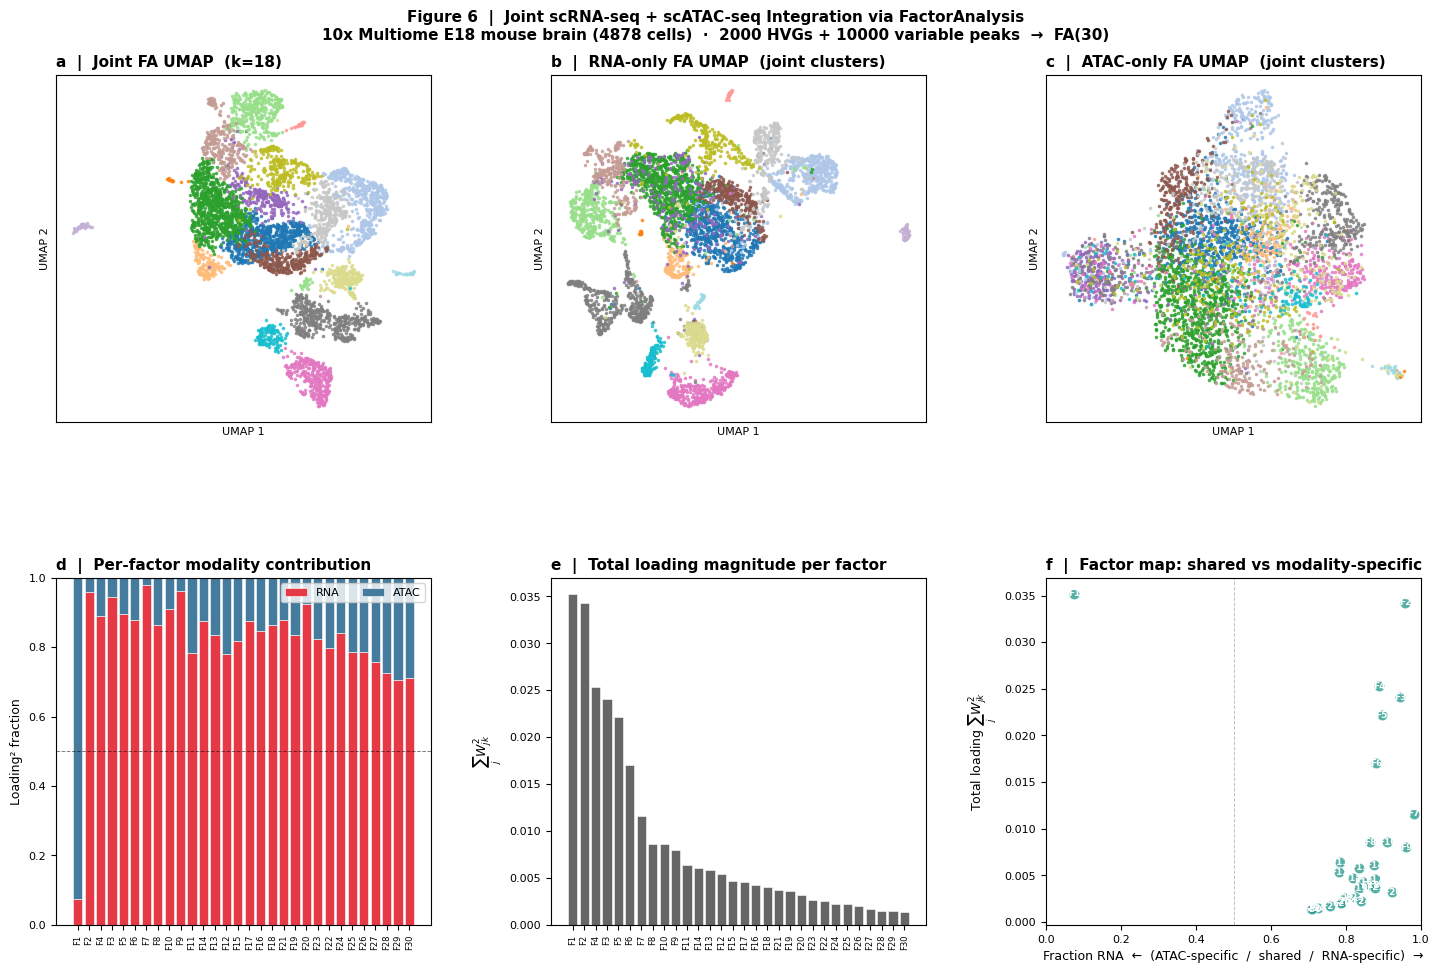

Saved figure → results/figure6_multiome_fa/Figure6_multiome_FA.pdf / .png


In [14]:
# ── Step 10: 6-panel summary figure ────────────────────────────────────────────────────────────
# Self-heal: if Step 6 was skipped or its leiden call silently failed, cluster here.
if 'leiden_joint' not in ad_joint.obs.columns:
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=12, random_state=SEED, n_init=10).fit(ad_joint.obsm['X_fa_joint'])
    ad_joint.obs['leiden_joint'] = pd.Categorical(km.labels_.astype(str))
    print('[note] leiden_joint missing — fell back to KMeans(k=12) on X_fa_joint')

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.32,
                        left=0.06, right=0.97, top=0.92, bottom=0.07)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])
ax_d = fig.add_subplot(gs[1, 0])
ax_e = fig.add_subplot(gs[1, 1])
ax_f = fig.add_subplot(gs[1, 2])

# Cluster palette
unique_clusters = sorted(ad_joint.obs['leiden_joint'].astype(str).unique(),
                         key=lambda c: int(c) if c.isdigit() else c)
n_clust = len(unique_clusters)
palette = plt.get_cmap('tab20')(np.linspace(0, 1, max(n_clust, 3)))
cluster_colors = {c: palette[i] for i, c in enumerate(unique_clusters)}

def _scatter_clusters(ax, X, labels, title, letter):
    for c, color in cluster_colors.items():
        m = labels == c
        ax.scatter(X[m, 0], X[m, 1], s=2.5, c=[color], alpha=0.75, rasterized=True, label=c)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('UMAP 1', fontsize=8); ax.set_ylabel('UMAP 2', fontsize=8)
    ax.set_title(f'{letter}  |  {title}', fontweight='bold', loc='left', fontsize=11)

labels = ad_joint.obs['leiden_joint'].astype(str).values
_scatter_clusters(ax_a, ad_joint.obsm['X_umap'],      labels, f'Joint FA UMAP  (k={n_clust})', 'a')
_scatter_clusters(ax_b, ad_joint.obsm['X_umap_rna'],  labels, 'RNA-only FA UMAP  (joint clusters)', 'b')
_scatter_clusters(ax_c, ad_joint.obsm['X_umap_atac'], labels, 'ATAC-only FA UMAP  (joint clusters)', 'c')

# Panel d — per-factor modality contribution (stacked bar)
order = np.argsort(-total)
x = np.arange(N_LATENT)
ax_d.bar(x, frac_rna[order],  color=MODALITY_COLORS['RNA'],  label='RNA', edgecolor='white', linewidth=0.4)
ax_d.bar(x, frac_atac[order], bottom=frac_rna[order], color=MODALITY_COLORS['ATAC'],
         label='ATAC', edgecolor='white', linewidth=0.4)
ax_d.axhline(0.5, color='black', lw=0.7, ls='--', alpha=0.5)
ax_d.set_xticks(x); ax_d.set_xticklabels([f'F{order[i]+1}' for i in range(N_LATENT)], rotation=90, fontsize=6)
ax_d.set_ylabel('Loading² fraction')
ax_d.set_ylim(0, 1)
ax_d.set_title('d  |  Per-factor modality contribution', fontweight='bold', loc='left', fontsize=11)
ax_d.legend(fontsize=8, loc='upper right', ncol=2)

# Panel e — total factor loading magnitude (variance explained proxy)
ax_e.bar(x, total[order], color='#666', edgecolor='white', linewidth=0.4)
ax_e.set_xticks(x); ax_e.set_xticklabels([f'F{order[i]+1}' for i in range(N_LATENT)], rotation=90, fontsize=6)
ax_e.set_ylabel(r'$\sum_j W_{jk}^2$')
ax_e.set_title('e  |  Total loading magnitude per factor', fontweight='bold', loc='left', fontsize=11)

# Panel f — RNA vs ATAC contribution scatter, labeled by factor #
ax_f.scatter(frac_rna, total, s=60, c=[MODALITY_COLORS['Joint']],
             alpha=0.8, edgecolors='white', linewidths=0.7)
for k in range(N_LATENT):
    ax_f.annotate(f'F{k+1}', (frac_rna[k], total[k]),
                  fontsize=6.5, ha='center', va='center', color='white', fontweight='bold')
ax_f.axvline(0.5, color='gray', lw=0.7, ls='--', alpha=0.5)
ax_f.set_xlabel('Fraction RNA  ←  (ATAC-specific  /  shared  /  RNA-specific)  →')
ax_f.set_ylabel(r'Total loading $\sum_j W_{jk}^2$')
ax_f.set_title('f  |  Factor map: shared vs modality-specific', fontweight='bold', loc='left', fontsize=11)
ax_f.set_xlim(0, 1)

fig.suptitle(
    'Figure 6  |  Joint scRNA-seq + scATAC-seq Integration via FactorAnalysis\n'
    f'10x Multiome E18 mouse brain ({ad_joint.n_obs} cells)  ·  '
    f'{N_HVG} HVGs + {N_VAR_PEAKS} variable peaks  →  FA({N_LATENT})',
    fontsize=11, fontweight='bold', y=0.985,
)
fig.savefig(OUTDIR + 'Figure6_multiome_FA.pdf', dpi=600, bbox_inches='tight')
fig.savefig(OUTDIR + 'Figure6_multiome_FA.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure → {OUTDIR}Figure6_multiome_FA.pdf / .png')


## Summary — What the joint FA recovered

In [15]:
# ── Summary ───────────────────────────────────────────────────────────────────────────
n_shared = int(((frac_rna > 0.3) & (frac_rna < 0.7)).sum())
n_rna_specific  = int((frac_rna  > 0.7).sum())
n_atac_specific = int((frac_atac > 0.7).sum())

print('=' * 70)
print('FIGURE 6 — JOINT MULTI-OMIC FA INTEGRATION')
print('=' * 70)
print(f'Cells:                  {ad_joint.n_obs}')
print(f'RNA HVGs:               {N_HVG}')
print(f'ATAC variable peaks:    {N_VAR_PEAKS}')
print(f'Joint FA factors:       {N_LATENT}')
print(f'Leiden clusters:        {ad_joint.obs["leiden_joint"].nunique()}')
print()
print('Factor categorization (by RNA loading fraction):')
print(f'  Shared    (0.3 < RNA frac < 0.7):  {n_shared}')
print(f'  RNA-driven       (RNA frac > 0.7): {n_rna_specific}')
print(f'  ATAC-driven     (ATAC frac > 0.7): {n_atac_specific}')
print()
print('Top 5 shared factors (top 3 genes / peaks each):')
shared_factors = contrib_df[(contrib_df['rna_frac'] > 0.3) & (contrib_df['rna_frac'] < 0.7)].head(5)
for _, row in shared_factors.iterrows():
    k = int(row['factor'])
    genes = [g for g,_ in factor_top[k]['top_genes'][:3]]
    peaks = [p for p,_ in factor_top[k]['top_peaks'][:3]]
    print(f'  F{k:<2}  RNA={row["rna_frac"]:.2f}  genes={genes}  peaks={peaks}')
print()
print(f'All outputs in: {OUTDIR}')

# Persist BOTH integrated AnnData objects so the follow-up drift+validation
# notebook can pick up exactly this run without recomputing the joint FA.
ad_joint.write(OUTDIR + 'adata_multiome_fa.h5ad')
ad_atac.write(OUTDIR  + 'adata_multiome_fa_atac.h5ad')
print(f'Saved RNA + joint latent  → {OUTDIR}adata_multiome_fa.h5ad')
print(f'Saved ATAC + FA loadings  → {OUTDIR}adata_multiome_fa_atac.h5ad')


FIGURE 6 — JOINT MULTI-OMIC FA INTEGRATION
Cells:                  4878
RNA HVGs:               2000
ATAC variable peaks:    10000
Joint FA factors:       30
Leiden clusters:        18

Factor categorization (by RNA loading fraction):
  Shared    (0.3 < RNA frac < 0.7):  0
  RNA-driven       (RNA frac > 0.7): 29
  ATAC-driven     (ATAC frac > 0.7): 1

Top 5 shared factors (top 3 genes / peaks each):

All outputs in: results/figure6_multiome_fa/
Saved RNA + joint latent  → results/figure6_multiome_fa/adata_multiome_fa.h5ad
Saved ATAC + FA loadings  → results/figure6_multiome_fa/adata_multiome_fa_atac.h5ad


In [16]:
pwd

'/Users/terooatt/Downloads/scJDO/Figures_notebook'